# Alzheimer MRI Classification using DenseNet50
Train / Validation split from train folder, augmentation, evaluation and prediction.

In [1]:
# ===============================
# 1 Import Libraries
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import DenseNet121 # Changed to DenseNet
from tensorflow.keras.applications.densenet import preprocess_input # Changed preprocessing
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Added ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight # For dynamic class weights
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [2]:
# ===============================
# 2 GPU Configuration
# ===============================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPUs:", gpus)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import shutil
import random
from pathlib import Path

def split_dataset(input_dir, output_dir, split_ratio=(0.7, 0.15, 0.15), seed=42):
    """
    Splits a dataset into train, val, and test sets.
    """
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    
    # Ensure ratios sum up to 1
    train_ratio, val_ratio, test_ratio = split_ratio
    assert round(train_ratio + val_ratio + test_ratio, 5) == 1.0, "Ratios must sum to 1.0"
    
    # The folders you specified
    classes = ['Mild Dementia', 'Moderate Dementia', 'Non Dementia','Very mild Dementia']
    splits = ['train', 'val', 'test']
    
    # 1. Create the output directory structure
    for split in splits:
        for cls in classes:
            (output_path / split / cls).mkdir(parents=True, exist_ok=True)
            
    # Set seed for reproducibility
    random.seed(seed)
    
    # 2. Distribute files for each class
    for cls in classes:
        cls_dir = input_path / cls
        
        if not cls_dir.exists():
            print(f"Warning: Directory '{cls_dir}' does not exist. Skipping.")
            continue
            
        # Get all files in the class directory (ignoring hidden files/folders)
        files = [f for f in cls_dir.iterdir() if f.is_file() and not f.name.startswith('.')]
        random.shuffle(files)
        
        # Calculate split indices
        total_files = len(files)
        train_idx = int(total_files * train_ratio)
        val_idx = train_idx + int(total_files * val_ratio)
        
        # Slice the list of files
        train_files = files[:train_idx]
        val_files = files[train_idx:val_idx]
        test_files = files[val_idx:]
        
        # Helper function to copy files
        def copy_files(file_list, split_name):
            for f in file_list:
                dest = output_path / split_name / cls / f.name
                shutil.copy2(f, dest) # copy2 preserves metadata
                
        # Execute the copy
        copy_files(train_files, 'train')
        copy_files(val_files, 'val')
        copy_files(test_files, 'test')
        
        print(f"Class '{cls}': Copied {len(train_files)} train, {len(val_files)} val, {len(test_files)} test.")

# --- Run the Script ---
# This assumes your original folder is named "dataset" 
# and you want the split folders inside a new folder called "split_dataset"
split_dataset(
    input_dir='Dataset_large', 
    output_dir='Dataset_large_split', 
    split_ratio=(0.70, 0.15, 0.15) # 70% Train, 15% Validation, 15% Test
)

Class 'Mild Dementia': Copied 3501 train, 750 val, 751 test.
Class 'Moderate Dementia': Copied 341 train, 73 val, 74 test.
Class 'Non Demented': Copied 47055 train, 10083 val, 10084 test.
Class 'Very mild Dementia': Copied 4776 train, 1023 val, 1025 test.


In [7]:
# ===============================
# 3 Paths and Parameters
# ===============================

TRAIN_DIR = "Dataset_large_split/train"
TEST_DIR = "Dataset_large_split/test"
VAL_DIR   = "Dataset_large_split/val"

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

CLASSES = [
'Mild Dementia',
'Moderate Dementia',
'Non Dementia',
'Very Mild Dementia'
]


In [8]:
# ===============================
# 4 Load Train Dataset
# ===============================

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    class_names=CLASSES, # Remember to keep this from our previous fix!
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 55673 files belonging to 4 classes.


In [9]:
# ===============================
# 5 Validation Dataset
# ===============================

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=SEED,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 11929 files belonging to 4 classes.


In [10]:
# ===============================
# 6 Test Dataset
# ===============================

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=CLASSES,
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Crucial: Never shuffle the test set so your confusion matrix lines up
)

Found 11934 files belonging to 4 classes.


In [11]:
# ===============================
# 7 Data Augmentation
# ===============================

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1,0.1),
])

def augment(images, labels):
    images = data_augmentation(images)
    return images, labels

train_dataset = train_dataset.map(augment)


In [12]:
# ===============================
# 8 DenseNet Preprocessing
# ===============================

def preprocess(images, labels):
    images = preprocess_input(images)
    return images, labels

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)


In [13]:
# ===============================
# 9 Prefetch for performance
# ===============================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)


In [14]:
# ===============================
# 10 Build DenseNet121 Model
# ===============================

base_model = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

# Unfreeze the top layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-75]:  # Freeze everything except the last 30 layers
    layer.trainable = False

model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4), # Reduced slightly for better learning
    layers.Dense(4, activation="softmax")
])

In [15]:
# ===============================
# 11 Compile Model
# ===============================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="acc"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               262400    
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                

In [16]:
# ===============================
# 12 Training
# ===============================


# Dynamically compute class weights
y_train = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in train_dataset])
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), weights))

# CRITICAL FIX: Cap the maximum weight so the model doesn't over-predict the rarest class
MAX_WEIGHT_CAP = 5.0 
class_weights = {k: min(v, MAX_WEIGHT_CAP) for k, v in class_weights.items()}

print(f"Capped Class Weights: {class_weights}")

# Callbacks
early_stop = EarlyStopping(
    monitor="val_acc",
    patience=10, 
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6
)

# Fit the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Capped Class Weights: {0: 3.9755069980005713, 1: 5.0, 2: 0.295786845181171, 3: 2.914206448911223}
Epoch 1/100
1740/1740 [==============================] - 621s 349ms/step - loss: 0.8386 - acc: 0.5520 - auc: 0.7731 - val_loss: 0.5117 - val_acc: 0.8155 - val_auc: 0.9546 - lr: 1.0000e-04
Epoch 2/100
1740/1740 [==============================] - 622s 358ms/step - loss: 0.4560 - acc: 0.7477 - auc: 0.9204 - val_loss: 0.3815 - val_acc: 0.8489 - val_auc: 0.9745 - lr: 1.0000e-04
Epoch 3/100
1740/1740 [==============================] - 596s 343ms/step - loss: 0.3193 - acc: 0.8157 - auc: 0.9569 - val_loss: 0.2608 - val_acc: 0.9039 - val_auc: 0.9868 - lr: 1.0000e-04
Epoch 4/100
1740/1740 [==============================] - 632s 363ms/step - loss: 0.2415 - acc: 0.8533 - auc: 0.9719 - val_loss: 0.1598 - val_acc: 0.9377 - val_auc: 0.9946 - lr: 1.0000e-04
Epoch 5/100
1740/1740 [==============================] - 600s 345ms/step - loss: 0.1981 - acc: 0.8769 - auc: 0.9799 - val_loss: 0.1821 - val_acc: 0.93

In [1]:
# ===============================
# 13 Plot Training Metrics
# ===============================

fig, ax = plt.subplots(1, 2, figsize = (30, 5))
ax = ax.ravel()

for i, metric in enumerate(["acc", "loss"]):
    ax[i].plot(history.history[metric])
    ax[i].plot(history.history["val_" + metric])
    ax[i].set_title("Model {}".format(metric))
    ax[i].set_xlabel("Epochs")
    ax[i].set_ylabel(metric)
    ax[i].legend(["train", "val"])

plt.show()


NameError: name 'plt' is not defined

In [18]:
# ===============================
# 14 Evaluate on Test Set
# ===============================

test_scores = model.evaluate(test_dataset)

print('Testing Accuracy: %.2f%%' % (test_scores[1] * 100))


373/373 [==============================] - 75s 201ms/step - loss: 0.0134 - acc: 0.9947 - auc: 0.9999
Testing Accuracy: 99.47%


In [19]:
# ===============================
# 15 Predictions
# ===============================

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(tf.argmax(labels, axis=1).numpy())
    y_pred.extend(tf.argmax(preds, axis=1).numpy())


1/1 [==============================] - 2s 2s/step


In [24]:
# ===============================
# 16 Classification Report
# ===============================

print(classification_report(y_true, y_pred, target_names=CLASSES))


                    precision    recall  f1-score   support

     Mild Dementia       0.99      1.00      0.99       751
 Moderate Dementia       0.99      1.00      0.99        74
      Non Dementia       1.00      1.00      1.00     10084
Very Mild Dementia       0.98      0.97      0.98      1025

          accuracy                           0.99     11934
         macro avg       0.99      0.99      0.99     11934
      weighted avg       0.99      0.99      0.99     11934



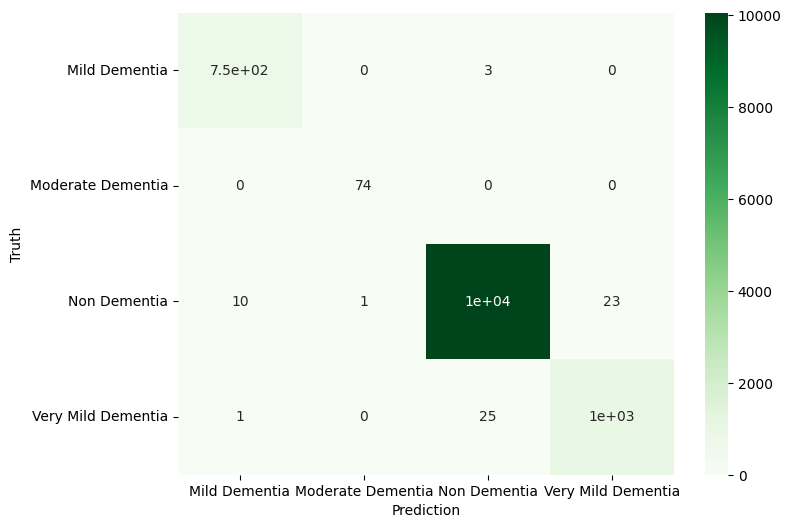

In [25]:
# ===============================
# 17 Confusion Matrix
# ===============================

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    conf_matrix,
    annot=True,
    cmap="Greens",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Prediction")
plt.ylabel("Truth")

plt.show()


In [26]:
# ===============================
# 18 Save Model
# ===============================

model.save("alzheimer_densenet2_model.keras")
print("Model saved.")


Model saved.
